# Prompt Evaluation

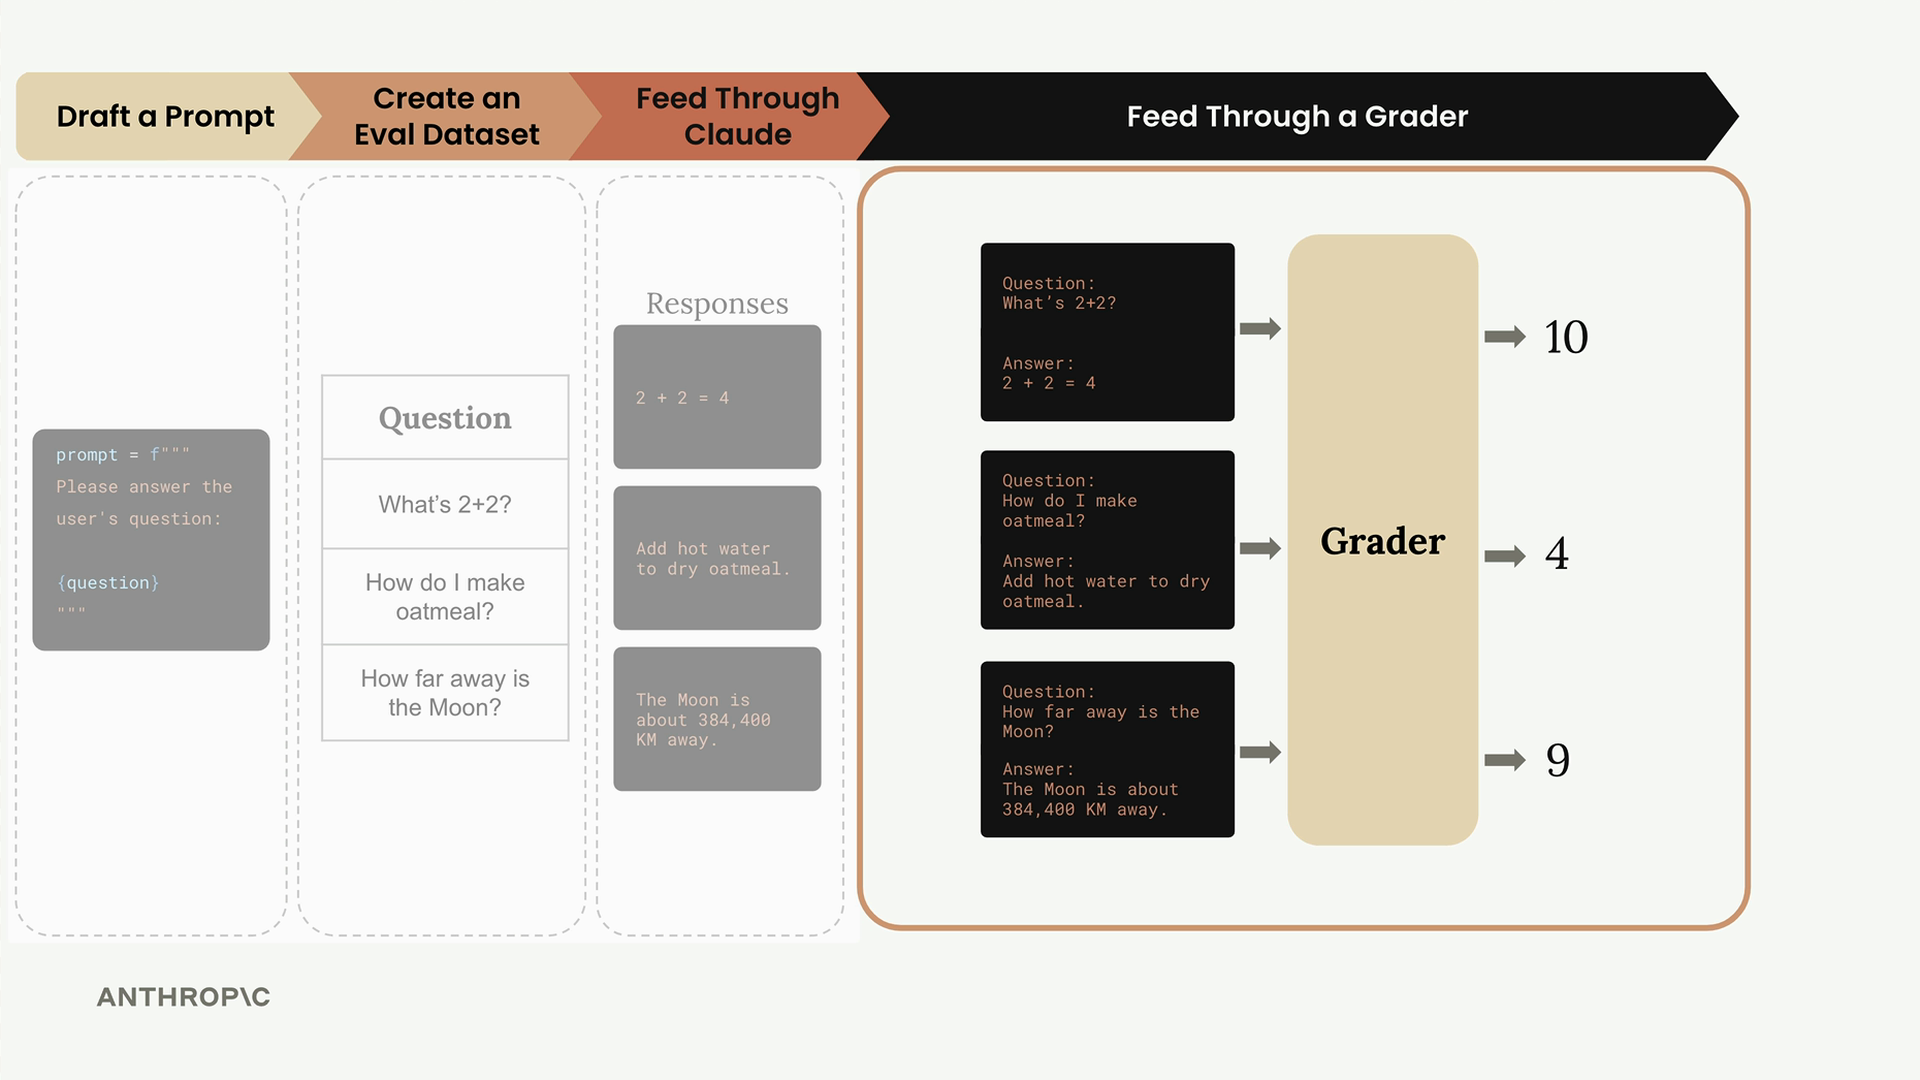

In [29]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [30]:
# Helper functions
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)


def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[]):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

## Building the Eval Dataset

In [67]:
import json


def generate_dataset():
    prompt = """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
        "format": "python" or "json" or "regex",
        "solution_criteria": "Key criteria for evaluating the solution"
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""
    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```json")
    text = chat(messages = messages, stop_sequences=["```"])

    return json.loads(text)

In [68]:
dataset = generate_dataset()
print("Generated dataset:", dataset)

Generated dataset: [{'task': 'Parse an AWS CloudWatch log entry and extract the timestamp, log level, and message using a regular expression', 'format': 'regex', 'solution_criteria': 'The regex should correctly capture timestamp in ISO 8601 format, log level (INFO, ERROR, WARN, DEBUG), and the remaining message content from a CloudWatch log line'}, {'task': 'Write a Python function that takes an AWS S3 bucket name and returns True if it follows AWS naming conventions (lowercase, 3-63 characters, starts with lowercase letter, no underscores)', 'format': 'python', 'solution_criteria': 'The function should validate all AWS S3 bucket naming rules and return a boolean value, handling edge cases like empty strings and special characters'}, {'task': "Create a JSON object that represents an AWS IAM policy document allowing read-only access to a specific S3 bucket with ARN 'arn:aws:s3:::my-bucket/*'", 'format': 'json', 'solution_criteria': "The JSON should be valid IAM policy syntax with correc

In [69]:
# Write the dataset to a JSON file
import os

os.makedirs("../datasets", exist_ok=True)

with open("../datasets/evaluation_dataset.json", "w") as f:
    json.dump(dataset, f, indent=2)

## Types Of Grader

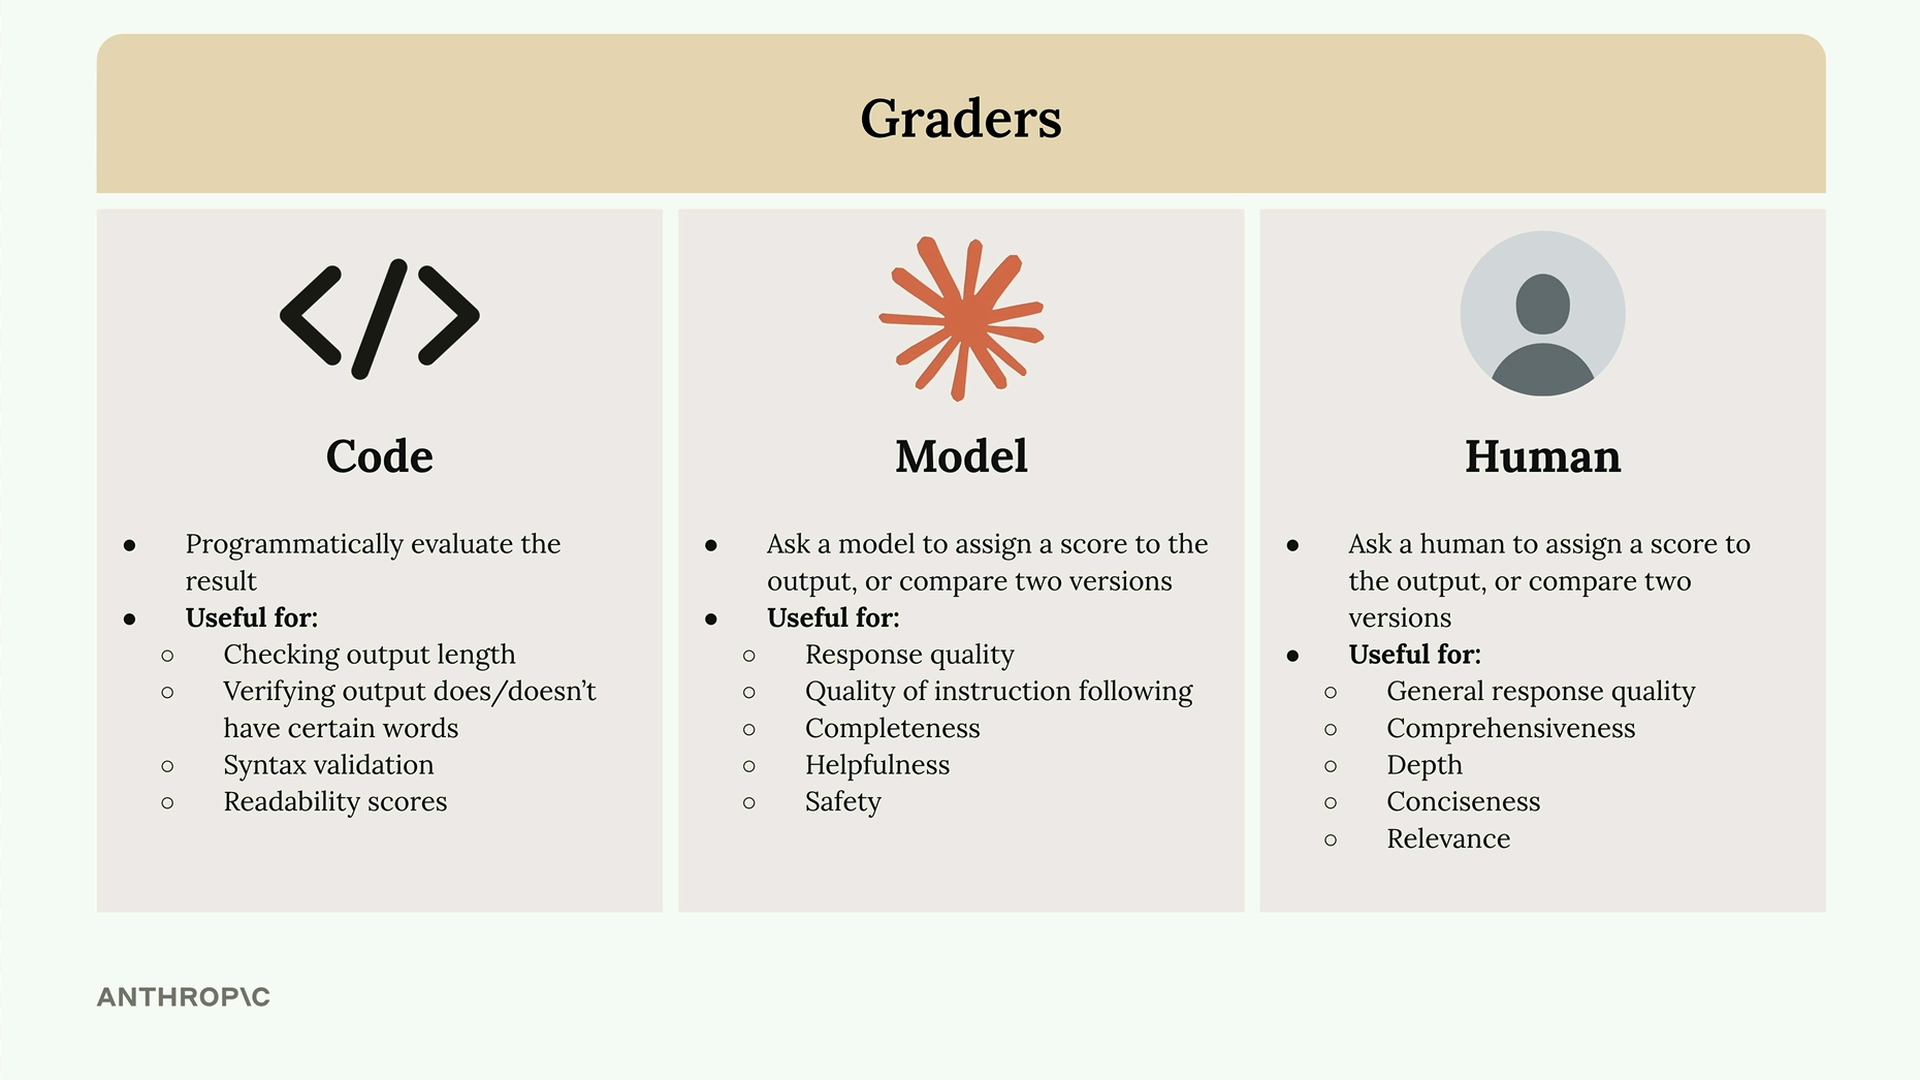

## Defining the Evaluation Criteria

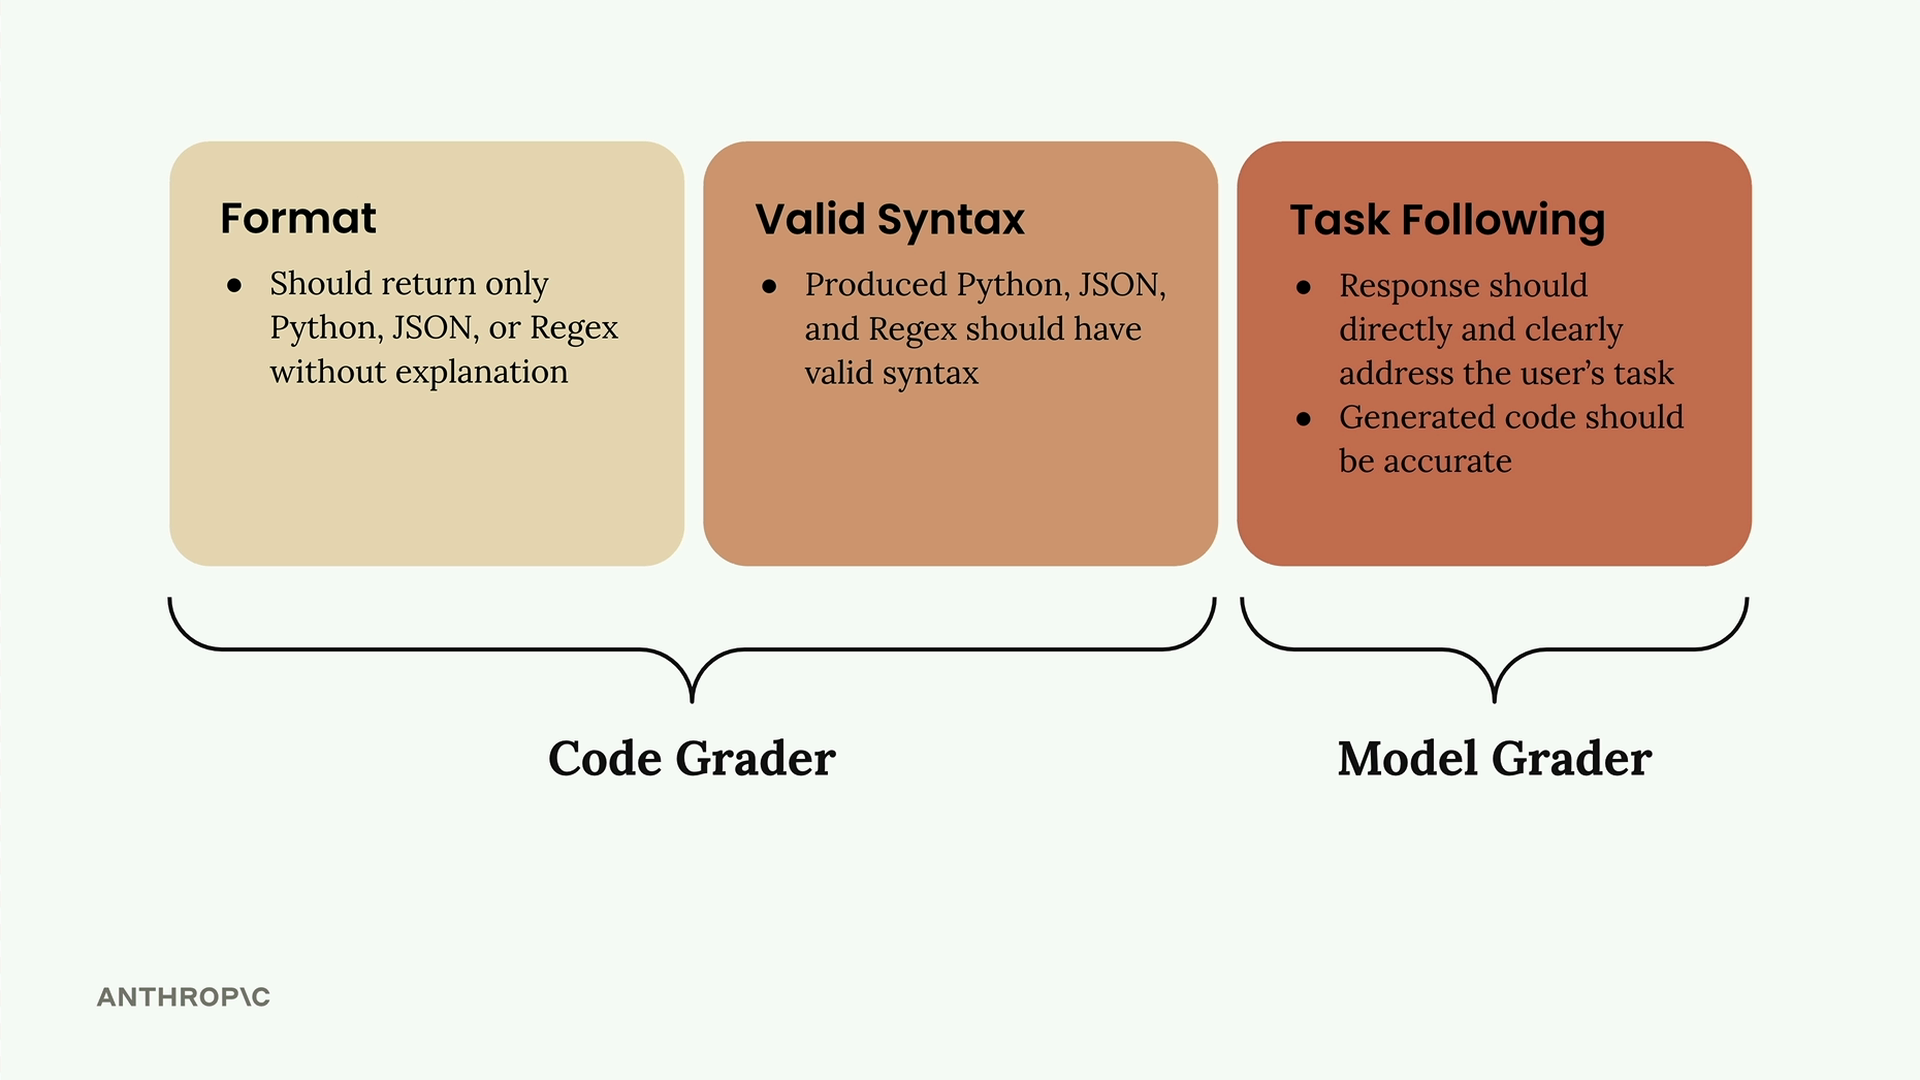

## Running the Eval Pipeline with Graders



In [70]:
# Function to grade a test case + output using a model
def grade_by_model(test_case, response):
    eval_prompt = f"""
You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution.

Original Task:
<task>
{test_case["task"]}
</task>

Solution to Evaluate:
<solution>
{response}
</solution>

Criteria you should use to evaluate the solution:
<criteria>
{test_case["solution_criteria"]}
</criteria>

Output Format
Provide your evaluation as a structured JSON object with the following fields, in this specific order:
- "strengths": An array of 1-3 key strengths
- "weaknesses": An array of 1-3 key areas for improvement
- "reasoning": A concise explanation of your overall assessment
- "score": A number between 1-10

Respond with JSON. Keep your response concise and direct.
Example response shape:
{{
    "strengths": string[],
    "weaknesses": string[],
    "reasoning": string,
    "score": number
}}
    """

    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, "```json")
    eval_text = chat(messages, stop_sequences=["```"])
    return json.loads(eval_text)

In [71]:
# Code Grader: Functions to validate the output structure
import re
import ast


def validate_json(text):
    try:
        json.loads(text.strip())
        return 10
    except json.JSONDecodeError:
        return 0


def validate_python(text):
    try:
        ast.parse(text.strip())
        return 10
    except SyntaxError:
        return 0


def validate_regex(text):
    try:
        re.compile(text.strip())
        return 10
    except re.error:
        return 0


def grade_syntax(response, test_case):
    format = test_case["format"]
    if format == "json":
        return validate_json(response)
    elif format == "python":
        return validate_python(response)
    else:
        return validate_regex(response)


In [72]:
# Passes a test case into Claude
def run_prompt(test_case):
    """ Merge the prompt with the test case and return the result. """
    prompt = f"""
Please solve the following task: 

{test_case["task"]}

* Respond only with Python, JSON, or plain Regex
* Do not include any explanations or comments or commentary.
"""
    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```code")
    output = chat(messages, stop_sequences=["```"])
    return output

In [73]:
# Function to execute a single test case and grade the output
def run_test_case(test_case):
    """ Calls run_prompt, then grades the result. """
    response = run_prompt(test_case)

    model_grade = grade_by_model(test_case=test_case, response=response)
    syntax_grade = grade_syntax(response=response, test_case=test_case)

    score = (model_grade["score"] + syntax_grade) / 2

    return {
        "output": response, 
        "test_case": test_case,  
        "score": score, 
        "model_reasoning": model_grade["reasoning"]
    }

In [74]:
from statistics import mean

def run_eval(dataset):
    """ Loads the dataset and calls run_test_case for each test case."""
    results = []
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)

    mean_score = mean([result["score"] for result in results])
    print(f"Mean Score: {mean_score}")
    
    return results

In [75]:
with open("../datasets/evaluation_dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)

Mean Score: 7.0


In [76]:
print(json.dumps(results, indent=2))

[
  {
    "output": "\nimport re\nimport json\n\ndef parse_cloudwatch_log(log_entry):\n    # AWS CloudWatch log format: timestamp level message\n    pattern = r'(\\d{4}-\\d{2}-\\d{2}T\\d{2}:\\d{2}:\\d{2}\\.\\d{3}Z)\\s+(\\w+)\\s+(.*)'\n    \n    match = re.match(pattern, log_entry)\n    \n    if match:\n        return {\n            \"timestamp\": match.group(1),\n            \"log_level\": match.group(2),\n            \"message\": match.group(3)\n        }\n    return None\n\n\n# Test cases\ntest_logs = [\n    \"2024-01-15T10:30:45.123Z INFO Starting application\",\n    \"2024-01-15T10:30:46.456Z ERROR Failed to connect to database\",\n    \"2024-01-15T10:30:47.789Z DEBUG Processing request ID: 12345\",\n    \"2024-01-15T10:30:48.012Z WARN Memory usage exceeded 80%\"\n]\n\nfor log in test_logs:\n    result = parse_cloudwatch_log(log)\n    print(json.dumps(result, indent=2))\n",
    "test_case": {
      "task": "Parse an AWS CloudWatch log entry and extract the timestamp, log level, and